In [1]:
# Statistics
from scipy.stats import chi2_contingency

# Data
import polars as pl

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Database
from dbconfig import engine

# Plot defaults
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment Ready.")

Environment Ready.


In [19]:
dot_ball_table = pl.read_database(
query = """
with match_level_cte as 
(select match_id,
inning,
batting_team, 
round(100.00 * count(*) filter (where total_runs = 0) / count(*), 2) as dot_ball_pct,
max(winner) as winner
from ipl_master_view
where inning in (1,2)
group by 
match_id,
inning,
batting_team)

select match_id,
max(case when inning = 1 then batting_team end) as inning_1_batting_team,
max(case when inning = 1 then dot_ball_pct end) as inning_1_dot_ball_pct,
max(case when inning = 2 then batting_team end) as inning_2_batting_team,
max(case when inning = 2 then dot_ball_pct end) as inning_2_dot_ball_pct,
max(winner) as winner
from match_level_cte
group by match_id
order by match_id;""",
connection = engine)

In [20]:
dot_ball_table = dot_ball_table.with_columns(
    (
        pl.col("inning_1_dot_ball_pct") -
        pl.col("inning_2_dot_ball_pct")
    ).alias("dot_ball_pct_diff")
)

In [23]:
dot_ball_table = dot_ball_table.with_columns(
    pl.when(
        pl.col("inning_1_dot_ball_pct") >
        pl.col("inning_2_dot_ball_pct")
    )
    .then(pl.col("inning_2_batting_team"))
    .otherwise(pl.col("inning_1_batting_team"))
    .alias("dot_ball_battle_winner")
)

In [25]:
dot_ball_table = dot_ball_table.with_columns(
    (
        pl.col("winner") == pl.col("dot_ball_battle_winner")
    ).alias("battle_winner_won")
)

In [27]:
dot_ball_table.group_by("battle_winner_won").len()
dot_ball_table["battle_winner_won"].mean()

0.6963302752293578

In [28]:
dot_ball_table.filter(
    pl.col("dot_ball_pct_diff").abs() <= 2
).height

238

In [53]:
dot_ball_table = dot_ball_table.with_columns(
    pl.when(pl.col("dot_ball_pct_diff").abs() <= 5)
      .then(pl.lit('0-5'))
    .when(pl.col("dot_ball_pct_diff").abs() <= 10)
      .then(pl.lit('5-10'))
    .when(pl.col("dot_ball_pct_diff").abs() <= 15)
      .then(pl.lit('10-15'))
    .otherwise(pl.lit('15+'))
    .alias("diff_bin")
)

In [54]:
dot_ball_table

match_id,inning_1_batting_team,inning_1_dot_ball_pct,inning_2_batting_team,inning_2_dot_ball_pct,winner,dot_ball_pct_diff,dot_ball_battle_winner,battle_winner_won,diff_bin
i64,str,"decimal[38,2]",str,"decimal[38,2]",str,"decimal[38,2]",str,bool,str
335982,"""Kolkata Knight Riders""",29.03,"""Royal Challengers Bengaluru""",49.50,"""Kolkata Knight Riders""",-20.47,"""Kolkata Knight Riders""",true,"""15+"""
335983,"""Chennai Super Kings""",27.42,"""Punjab Kings""",18.55,"""Chennai Super Kings""",8.87,"""Punjab Kings""",false,"""5-10"""
335984,"""Rajasthan Royals""",44.26,"""Delhi Capitals""",31.96,"""Delhi Capitals""",12.30,"""Delhi Capitals""",true,"""10-15"""
335985,"""Mumbai Indians""",36.59,"""Royal Challengers Bengaluru""",29.27,"""Royal Challengers Bengaluru""",7.32,"""Royal Challengers Bengaluru""",true,"""5-10"""
335986,"""Sunrisers Hyderabad""",52.54,"""Kolkata Knight Riders""",50.00,"""Kolkata Knight Riders""",2.54,"""Kolkata Knight Riders""",true,"""0-5"""
…,…,…,…,…,…,…,…,…,…
1426307,"""Punjab Kings""",25.60,"""Sunrisers Hyderabad""",26.23,"""Sunrisers Hyderabad""",-0.63,"""Punjab Kings""",false,"""0-5"""
1426309,"""Sunrisers Hyderabad""",34.68,"""Kolkata Knight Riders""",32.14,"""Kolkata Knight Riders""",2.54,"""Kolkata Knight Riders""",true,"""0-5"""
1426310,"""Royal Challengers Bengaluru""",30.33,"""Rajasthan Royals""",28.57,"""Rajasthan Royals""",1.76,"""Rajasthan Royals""",true,"""0-5"""


In [55]:
plot_df = (dot_ball_table.group_by("diff_bin").agg(
    [
        pl.len().alias("matches"),
        (pl.col("battle_winner_won").mean() * 100.00).alias("win_rate")
    ]
).sort("win_rate", descending = True))

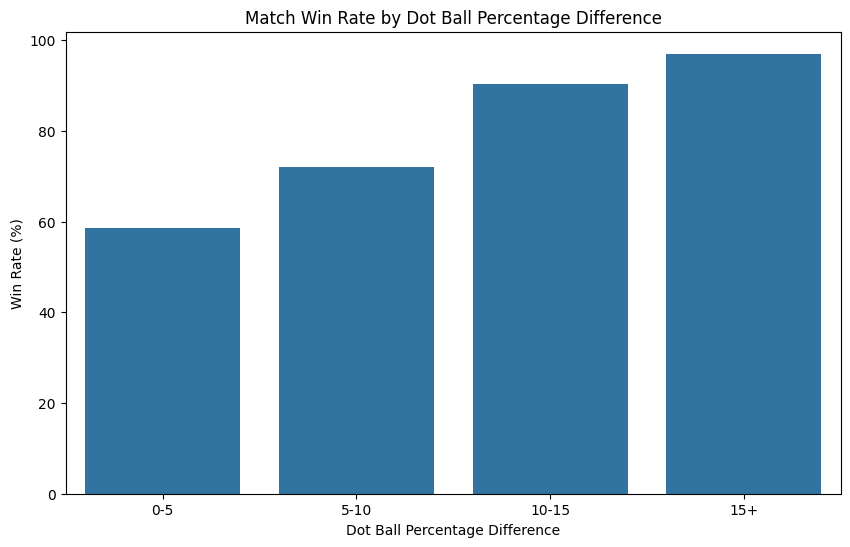

In [56]:
sns.barplot(data = plot_df, x = 'diff_bin', y = 'win_rate', order = ['0-5','5-10','10-15','15+'])
plt.ylabel('Win Rate (%)')
plt.xlabel('Dot Ball Percentage Difference')
plt.title('Match Win Rate by Dot Ball Percentage Difference')
plt.savefig(
    "plots/dot_ball_win_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()